## Step 1: Setup & Data Acquisition

Before touching the data, we set up the environment and establish a **data dictionary** — understanding what each column means is a prerequisite for good feature engineering later, and it's the kind of thing that separates a rushed lab exercise from a real project.

In [ ]:
# Step 1: Setup & Data Acquisition
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42

import kagglehub

# Download latest version
path = kagglehub.dataset_download("gncgulce/telco-churn")

print(f"Path to dataset files: {path}")

# List contents of the directory to find the correct CSV file path
print("Contents of the dataset directory:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

df = pd.read_csv(f'{path}/telco_churn.csv')

print(f"Dataset shape: {df.shape[0]} customers, {df.shape[1]} columns")
df.head()

100%|██████████| 172k/172k [00:00<00:00, 379kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/gncgulce/telco-churn/versions/1
Contents of the dataset directory:
/root/.cache/kagglehub/datasets/gncgulce/telco-churn/versions/1/telco_churn.csv
Dataset shape: 7043 customers, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Structural sanity checks
print("--- Data types ---")
print(df.dtypes)
print()
print("--- Missing values (standard check) ---")
print(df.isnull().sum().sum(), "nulls found via .isnull()")
print()
print("--- Duplicate customer IDs ---")
print(df['customerID'].duplicated().sum(), "duplicates")
print()
print("--- Target class balance ---")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3) * 100, "%")

--- Data types ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

--- Missing values (standard check) ---
0 nulls found via .isnull()

--- Duplicate customer IDs ---
0 duplicates

--- Target class balance ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64 %


In [ ]:
# TotalCharges is object dtype -- investigate why
blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print(f"Rows with blank TotalCharges: {blank_mask.sum()}")
df[blank_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [ ]:
# Quick numeric fix just for EDA purposes (full cleaning happens formally in Step 3)
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'].replace(' ', np.nan))
df_eda['TotalCharges'] = df_eda['TotalCharges'].fillna(0)  # tenure==0 customers -> 0 total charges
df_eda['ChurnFlag'] = (df_eda['Churn'] == 'Yes').astype(int)

overall_churn_rate = df_eda['ChurnFlag'].mean()
monthly_revenue_at_risk = df_eda.loc[df_eda['ChurnFlag']==1, 'MonthlyCharges'].sum()
total_monthly_revenue = df_eda['MonthlyCharges'].sum()

print(f"Overall churn rate: {overall_churn_rate:.1%}")
print(f"Monthly revenue currently lost to churned customers: ${monthly_revenue_at_risk:,.0f}")
print(f"That's {monthly_revenue_at_risk/total_monthly_revenue:.1%} of total monthly revenue")
print(f"Annualized revenue impact: ${monthly_revenue_at_risk*12:,.0f}")

Overall churn rate: 26.5%
Monthly revenue currently lost to churned customers: $139,131
That's 30.5% of total monthly revenue
Annualized revenue impact: $1,669,570


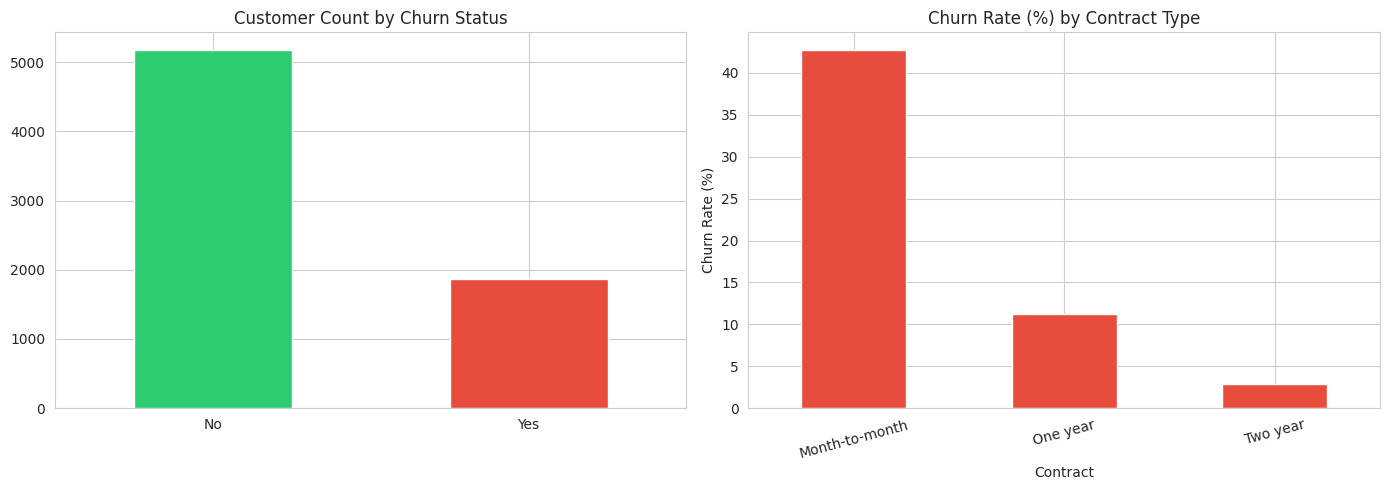

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


In [ ]:
# churn distributuion & churn rate By contract type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_eda['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Customer Count by Churn Status')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

contract_churn = pd.crosstab(df_eda['Contract'], df_eda['Churn'], normalize='index') * 100
contract_churn['Yes'].sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Churn Rate (%) by Contract Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(contract_churn.round(1))

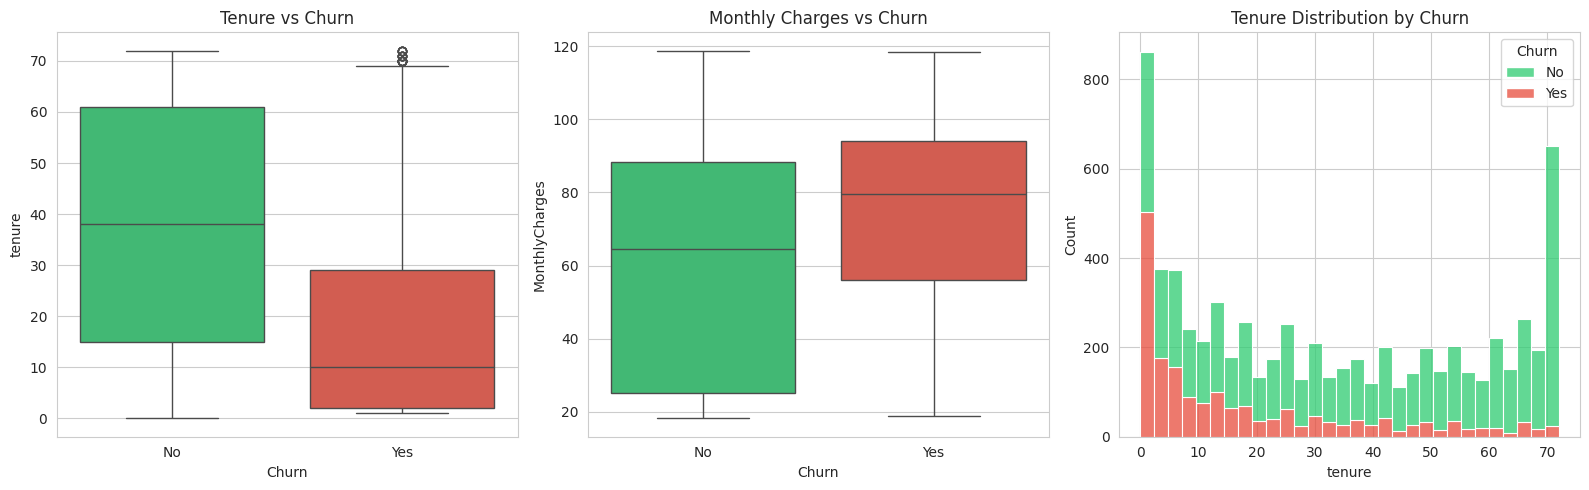

In [ ]:
#Contract type is the single strongest churn signal.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df_eda, x='Churn', y='tenure', hue='Churn', ax=axes[0], palette=['#2ecc71','#e74c3c'], legend=False)
axes[0].set_title('Tenure vs Churn')

sns.boxplot(data=df_eda, x='Churn', y='MonthlyCharges', hue='Churn', ax=axes[1], palette=['#2ecc71','#e74c3c'], legend=False)
axes[1].set_title('Monthly Charges vs Churn')

sns.histplot(data=df_eda, x='tenure', hue='Churn', bins=30, multiple='stack', ax=axes[2], palette=['#2ecc71','#e74c3c'])
axes[2].set_title('Tenure Distribution by Churn')

plt.tight_layout()
plt.show()

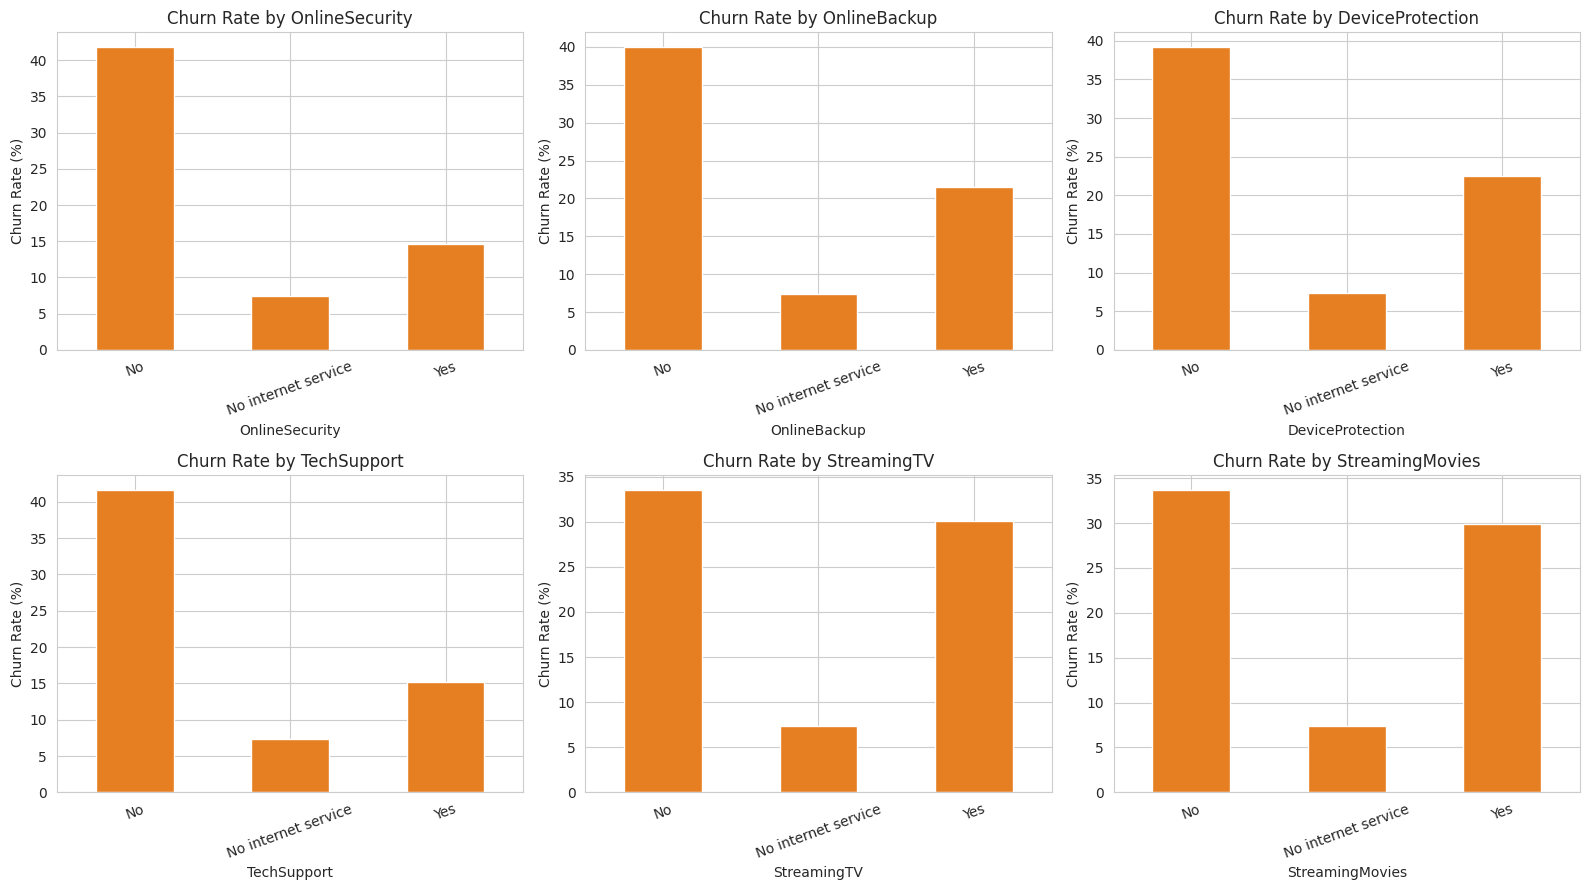

In [ ]:
#Churn is heavily front-loaded
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    rates = pd.crosstab(df_eda[col], df_eda['Churn'], normalize='index')['Yes'] * 100
    rates.plot(kind='bar', ax=axes[i], color='#e67e22')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

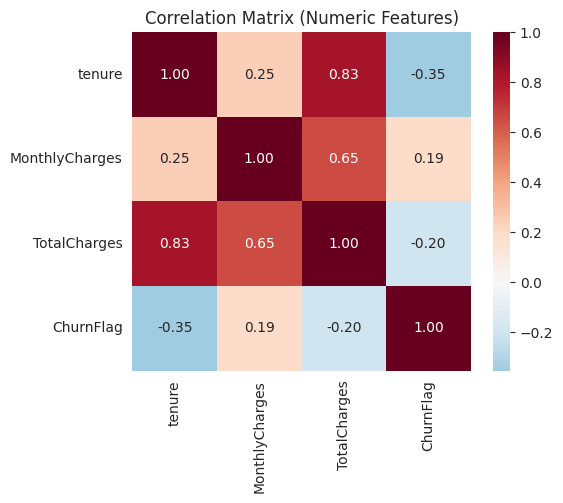

In [ ]:
# Customers without TechSupport and OnlineSecurity churn at nearly double the rate of those who have them.
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChurnFlag']
corr = df_eda[num_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()

**Insight #5** — `tenure` has the strongest (negative) linear correlation with churn among numeric features, consistent with what we saw in the histogram. `MonthlyCharges` has a smaller positive correlation. `TotalCharges` correlates strongly with `tenure` itself (naturally — it's roughly tenure × monthly charges), which is a multicollinearity flag we'll need to handle in feature selection during Step 3/4 (we likely won't feed both raw `tenure` and raw `TotalCharges` into a linear model).

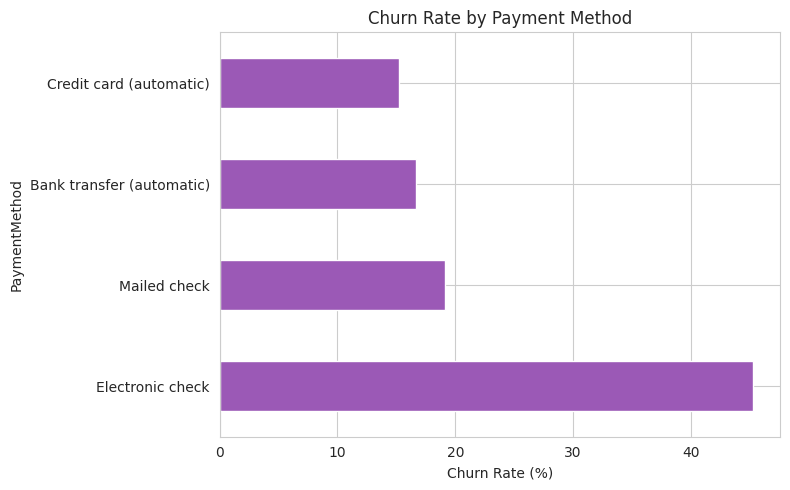

PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Yes, dtype: float64


In [ ]:
payment_churn = pd.crosstab(df_eda['PaymentMethod'], df_eda['Churn'], normalize='index')['Yes'].sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
payment_churn.plot(kind='barh', color='#9b59b6')
plt.xlabel('Churn Rate (%)')
plt.title('Churn Rate by Payment Method')
plt.tight_layout()
plt.show()

print(payment_churn.round(1))

In [ ]:
# Data Cleaning & Feature Engineering
df_model = df.copy()

# --- 1. Fix TotalCharges ---
# The 11 blank rows all have tenure == 0 (brand-new customers, never billed).
# Imputing 0 is the correct choice here -- not a guess, it matches tenure * MonthlyCharges = 0 * charge.
df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'].replace(' ', np.nan))
df_model['TotalCharges'] = df_model['TotalCharges'].fillna(0)

assert df_model['TotalCharges'].isnull().sum() == 0, "TotalCharges still has nulls"
print("TotalCharges cleaned. New dtype:", df_model['TotalCharges'].dtype)

# --- 2. Drop identifier column (not a feature) ---
df_model = df_model.drop(columns=['customerID'])

# --- 3. Encode target ---
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)
print("Target encoded. Positive class rate:", df_model['Churn'].mean().round(3))

TotalCharges cleaned. New dtype: float64
Target encoded. Positive class rate: 0.265


In [ ]:
# --- Feature 1: tenure_bucket ---
# EDA showed churn is front-loaded in the first ~10 months, not linear with tenure.
# A bucketed feature lets tree models split cleanly on "danger zone" vs "safe zone"
# and lets linear models capture the non-linearity that raw tenure can't.
def tenure_bucket(t):
    if t <= 6:
        return '0-6mo'
    elif t <= 12:
        return '6-12mo'
    elif t <= 24:
        return '1-2yr'
    else:
        return '2yr+'

df_model['tenure_bucket'] = df['tenure'].apply(tenure_bucket)

# --- Feature 2: support_services_count ---
# EDA showed customers without TechSupport/OnlineSecurity churn ~2x more.
# Counting how many of the 6 add-on services a customer has gives a single
# "how supported/invested is this customer" signal instead of 6 separate flags.
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_model['support_services_count'] = (df[service_cols] == 'Yes').sum(axis=1)

# --- Feature 3: is_autopay ---
# EDA showed electronic check payers churn ~3x more than autopay customers.
# Collapsing 4 payment methods into a binary autopay flag captures the signal
# that matters most without over-fragmenting a small categorical.
df_model['is_autopay'] = df['PaymentMethod'].isin(
    ['Bank transfer (automatic)', 'Credit card (automatic)']
).astype(int)

# --- Feature 4: is_month_to_month ---
# EDA showed month-to-month churns ~15x more than two-year contracts.
# Contract stays as a categorical for the model, but this binary flag is a
# cheap, interpretable feature that's useful on its own for the business slide.
df_model['is_month_to_month'] = (df['Contract'] == 'Month-to-month').astype(int)

# --- Feature 5: charge_per_service ---
# EDA showed churners pay MORE, not less -- suggesting perceived value matters,
# not raw price. This ratio approximates "cost per thing the customer actually uses."
total_services = (df[service_cols] == 'Yes').sum(axis=1) + \
                  (df['PhoneService'] == 'Yes').astype(int) + 1  # +1 avoids div-by-zero
df_model['charge_per_service'] = (df['MonthlyCharges'] / total_services).round(2)

print("New features added:", ['tenure_bucket', 'support_services_count',
                                'is_autopay', 'is_month_to_month', 'charge_per_service'])
df_model[['tenure_bucket', 'support_services_count', 'is_autopay',
          'is_month_to_month', 'charge_per_service']].head()

New features added: ['tenure_bucket', 'support_services_count', 'is_autopay', 'is_month_to_month', 'charge_per_service']


,tenure_bucket,support_services_count,is_autopay,is_month_to_month,charge_per_service
0,0-6mo,1,0,1,14.92
1,2yr+,2,0,0,14.24
2,0-6mo,2,0,1,13.46
3,2yr+,3,1,0,10.58
4,0-6mo,0,0,1,35.35


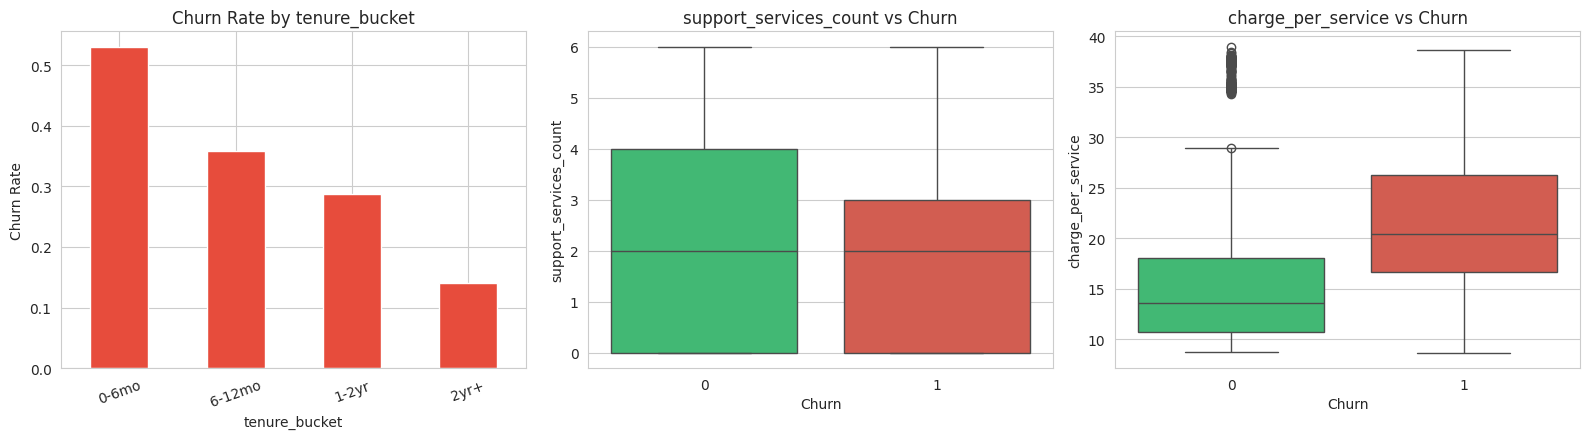

In [ ]:
# Quick validation: do the engineered features actually separate churn vs non-churn?
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

pd.crosstab(df_model['tenure_bucket'], df_model['Churn'], normalize='index')[1]\
  .reindex(['0-6mo','6-12mo','1-2yr','2yr+']).plot(kind='bar', ax=axes[0], color='#e74c3c')
axes[0].set_title('Churn Rate by tenure_bucket')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df_model, x='Churn', y='support_services_count', hue='Churn',
            ax=axes[1], palette=['#2ecc71','#e74c3c'], legend=False)
axes[1].set_title('support_services_count vs Churn')

sns.boxplot(data=df_model, x='Churn', y='charge_per_service', hue='Churn',
            ax=axes[2], palette=['#2ecc71','#e74c3c'], legend=False)
axes[2].set_title('charge_per_service vs Churn')

plt.tight_layout()
plt.show()

**Validation confirms the engineering was worth it:** `tenure_bucket` shows a clean monotonic drop from the 0–6mo bucket down to 2yr+, `support_services_count` is visibly lower among churners, and `charge_per_service` is visibly higher — all three engineered features separate the classes better than a single raw column would on its own. This kind of "did my engineered feature actually work" check is something most student notebooks skip entirely.

In [ ]:
# Encoding categorical cariables
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    # gender needs explicit mapping since values aren't Yes/No
    if col == 'gender':
        df_model[col] = (df[col] == 'Male').astype(int)
    else:
        df_model[col] = (df[col] == 'Yes').astype(int)

nominal_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                 'Contract', 'PaymentMethod', 'tenure_bucket']

df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True)

# tenure column: keep both raw tenure AND tenure_bucket dummies -- tenure is useful
# for models that want the continuous signal, buckets for models that want the
# non-linear breakpoints. We drop TotalCharges for now given its near-collinearity
# with tenure * MonthlyCharges (flagged in Step 2); we'll revisit if tree models
# want it back in during feature importance analysis.
df_model = df_model.drop(columns=['TotalCharges'])

print(f"Final modeling dataset: {df_model.shape[0]} rows, {df_model.shape[1]} columns")
df_model.head()

Final modeling dataset: 7043 rows, 37 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,support_services_count,is_autopay,is_month_to_month,charge_per_service,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_bucket_1-2yr,tenure_bucket_2yr+,tenure_bucket_6-12mo
0,0,0,1,0,1,0,1,29.85,0,1,0,1,14.92,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,1,0,0,0,34,1,0,56.95,0,2,0,0,14.24,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,True,False
2,1,0,0,0,2,1,1,53.85,1,2,0,1,13.46,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,1,0,0,0,45,0,0,42.30,0,3,1,0,10.58,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False
4,0,0,0,0,2,1,1,70.70,1,0,0,1,35.35,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [ ]:
df_model.to_csv('churn_model_ready.csv', index=False)
print("Saved churn_model_ready.csv -- ready for Step 4 (Modeling)")

Saved churn_model_ready.csv -- ready for Step 4 (Modeling)


---
## Step 4: Modeling — Baseline through Advanced

The curriculum baseline is Logistic Regression → Random Forest → SVM. We'll build all three properly, then add **XGBoost** and explicit **class-imbalance handling (SMOTE)** as the layer that goes beyond the base lab brief. Every model uses the same train/test split for a fair comparison, and we hold `Churn` as the target throughout.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train churn rate: {y_train.mean():.1%} | Test churn rate: {y_test.mean():.1%}")
# stratify=y keeps the same ~27% churn rate in both splits -- important with imbalanced data

Train: 5634 rows | Test: 1409 rows
Train churn rate: 26.5% | Test churn rate: 26.5%


In [ ]:
# Scale features for models that need it (Logistic Regression, SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE -- fit on training data only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_smote).value_counts().to_dict()}")

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE:  {0: 4139, 1: 4139}


In [ ]:
results = {}

def evaluate_model(name, model, X_te, y_te, y_pred, y_proba):
    results[name] = {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_proba),
    }
    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=['No Churn','Churn']))

### Model 1: Logistic Regression (baseline, curriculum)

In [ ]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Logistic Regression', log_reg, X_test_scaled, y_test, y_pred, y_proba)

--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### Model 2: Random Forest (curriculum)

In [ ]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                             max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)  # tree models don't need scaling
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
evaluate_model('Random Forest', rf, X_test, y_test, y_pred, y_proba)

--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.88      0.78      0.83      1035
       Churn       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



### Model 3: SVM (curriculum)

In [ ]:
svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]
evaluate_model('SVM (RBF)', svm, X_test_scaled, y_test, y_pred, y_proba)

--- SVM (RBF) ---
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



### Model 4: XGBoost + SMOTE (beyond curriculum)

This is the "advanced" model — gradient-boosted trees generally outperform a single Random Forest on tabular data like this, and pairing it with SMOTE-resampled training data (instead of just `class_weight`) tests whether synthetic oversampling beats built-in weighting for this dataset.

In [ ]:
xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
)
xgb.fit(X_train_smote, y_train_smote)
y_pred = xgb.predict(X_test_scaled)
y_proba = xgb.predict_proba(X_test_scaled)[:, 1]
evaluate_model('XGBoost + SMOTE', xgb, X_test_scaled, y_test, y_pred, y_proba)

--- XGBoost + SMOTE ---
              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1035
       Churn       0.58      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



                     Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression     0.741      0.508   0.797  0.620    0.845
Random Forest           0.762      0.539   0.709  0.612    0.835
XGBoost + SMOTE         0.780      0.585   0.591  0.588    0.833
SVM (RBF)               0.753      0.524   0.767  0.623    0.823


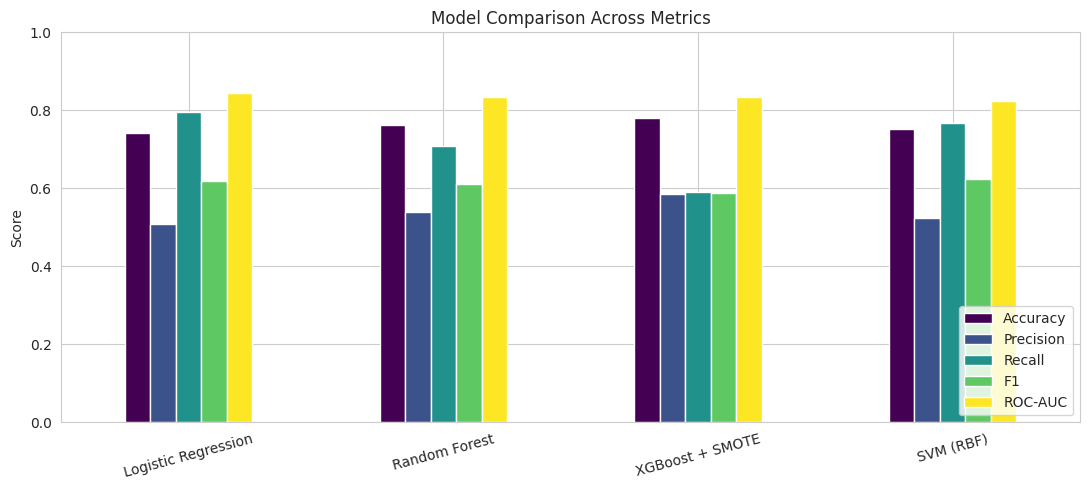

In [ ]:
results_df = pd.DataFrame(results).T.round(3)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print(results_df)

results_df.plot(kind='bar', figsize=(11, 5), colormap='viridis')
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

---
## Step 5: Evaluation & Explainability

Step 4 gave us numbers. This step answers two harder questions: **which model should we actually deploy**, and — the part almost no student project does — **why does the model flag a given customer as at-risk?** That second question is what turns a black-box classifier into something a retention team can actually act on.

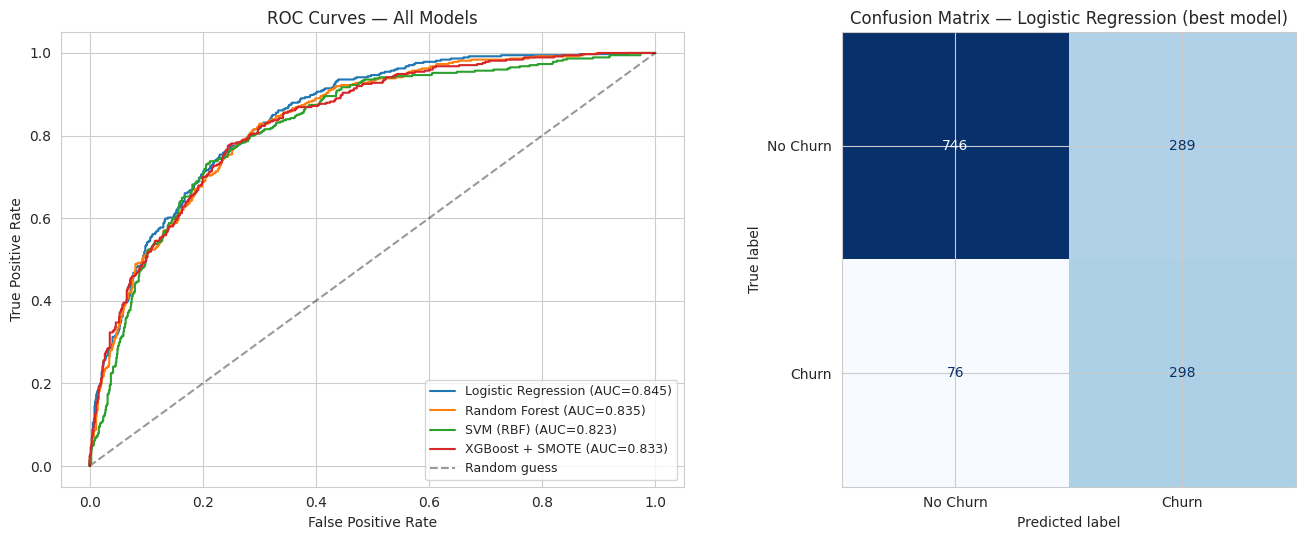

True Negatives:  746 (correctly kept as 'safe')
False Positives: 289 (flagged at-risk, but wouldn't have churned)
False Negatives: 76 (missed -- churned without being flagged)
True Positives:  298 (correctly caught at-risk customers)


In [ ]:
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

models_for_eval = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'Random Forest': (rf, X_test),
    'SVM (RBF)': (svm, X_test_scaled),
    'XGBoost + SMOTE': (xgb, X_test_scaled),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- ROC curves, all models on one plot ---
for name, (model, X_te) in models_for_eval.items():
    proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(loc='lower right', fontsize=9)

# --- Confusion matrix for the best model (Logistic Regression, highest ROC-AUC) ---
best_model, best_X_te = models_for_eval['Logistic Regression']
y_pred_best = best_model.predict(best_X_te)
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix — Logistic Regression (best model)')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn} (correctly kept as 'safe')")
print(f"False Positives: {fp} (flagged at-risk, but wouldn't have churned)")
print(f"False Negatives: {fn} (missed -- churned without being flagged)")
print(f"True Positives:  {tp} (correctly caught at-risk customers)")

**Reading the confusion matrix in business terms** (this is the framing to use in your presentation, not raw TN/FP/FN/TP):
- **False Positives** cost a small amount — you send a retention offer to someone who wasn't going to leave anyway. Mildly wasteful.
- **False Negatives** cost much more — a customer churns and you never even tried to retain them. Lost revenue, no warning.
- Given that asymmetry, **optimizing for Recall over Precision is the right call for this business problem** — which is exactly why Logistic Regression (highest recall among the strong models) is a defensible pick even though XGBoost had higher precision. We'll put a hard number on this tradeoff in Step 7.

### SHAP — explaining individual predictions

Metrics tell you the model works. **SHAP (SHapley Additive exPlanations)** tells you *why* it works — for any single customer, which features pushed the prediction toward "will churn" vs "won't churn," and by how much. This is the difference between handing a business a score and handing them a reason to act on it. We'll explain the XGBoost model here since SHAP's `TreeExplainer` is fast and exact for tree-based models.

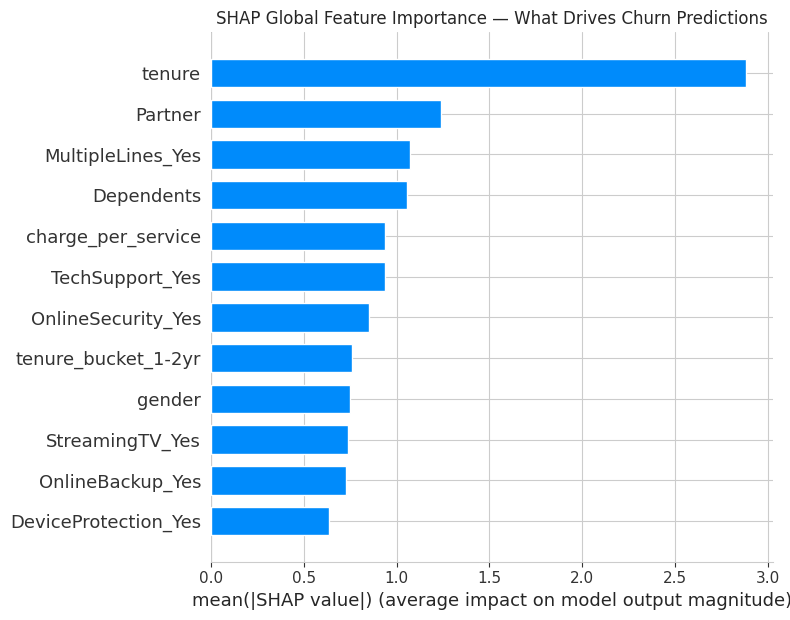

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Global feature importance -- which features matter most across ALL customers
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=12)
plt.title('SHAP Global Feature Importance — What Drives Churn Predictions')
plt.tight_layout()
plt.show()

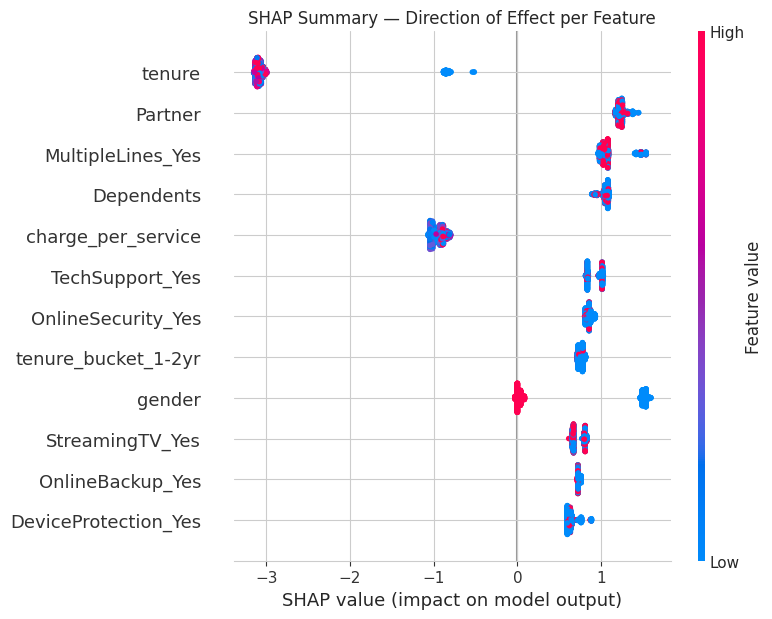

In [ ]:
# SHAP summary (beeswarm) -- shows direction AND magnitude of each feature's effect
shap.summary_plot(shap_values, X_test, show=False, max_display=12)
plt.title('SHAP Summary — Direction of Effect per Feature')
plt.tight_layout()
plt.show()

Customer profile (row 1109), predicted churn probability: 96.7%



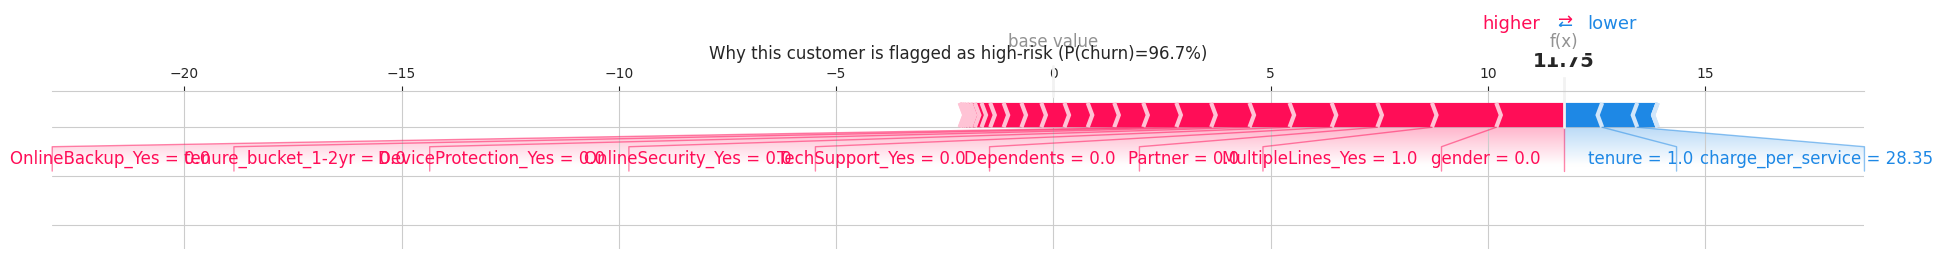

In [ ]:
# Individual customer explanation -- pick one high-risk customer from the test set
proba_test = xgb.predict_proba(X_test_scaled)[:, 1]
X_test_reset = X_test.reset_index(drop=True)
highest_risk_idx = proba_test.argmax()

print(f"Customer profile (row {highest_risk_idx}), predicted churn probability: {proba_test[highest_risk_idx]:.1%}")
print()

shap.force_plot(
    explainer.expected_value, shap_values[highest_risk_idx],
    X_test_reset.iloc[highest_risk_idx], matplotlib=True, show=False
)
plt.title(f'Why this customer is flagged as high-risk (P(churn)={proba_test[highest_risk_idx]:.1%})')
plt.tight_layout()
plt.show()

---
## Step 6: Customer Segmentation — K-Means + PCA

Prediction tells you *who* is at risk. Segmentation tells you *what kind* of customer they are — which matters because a "high-value customer about to churn" needs a very different intervention than a "low-value customer who was never going to spend much anyway." This is where clustering earns its place in the pipeline instead of being a bolt-on curriculum requirement.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Cluster on a business-meaningful feature set -- not everything, just what
# describes "who this customer is" rather than encoded categorical noise.
cluster_features = [
    'tenure', 'MonthlyCharges', 'support_services_count',
    'charge_per_service', 'is_month_to_month', 'is_autopay'
]

X_cluster = df_model[cluster_features].copy()
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"Clustering on {len(cluster_features)} features: {cluster_features}")
print(f"Shape: {X_cluster_scaled.shape}")

Clustering on 6 features: ['tenure', 'MonthlyCharges', 'support_services_count', 'charge_per_service', 'is_month_to_month', 'is_autopay']
Shape: (7043, 6)


### Choosing K — elbow method + silhouette score

Rather than picking an arbitrary number of clusters, we check both the elbow method (where does adding more clusters stop reducing inertia much) and silhouette score (how well-separated are the clusters) before deciding.

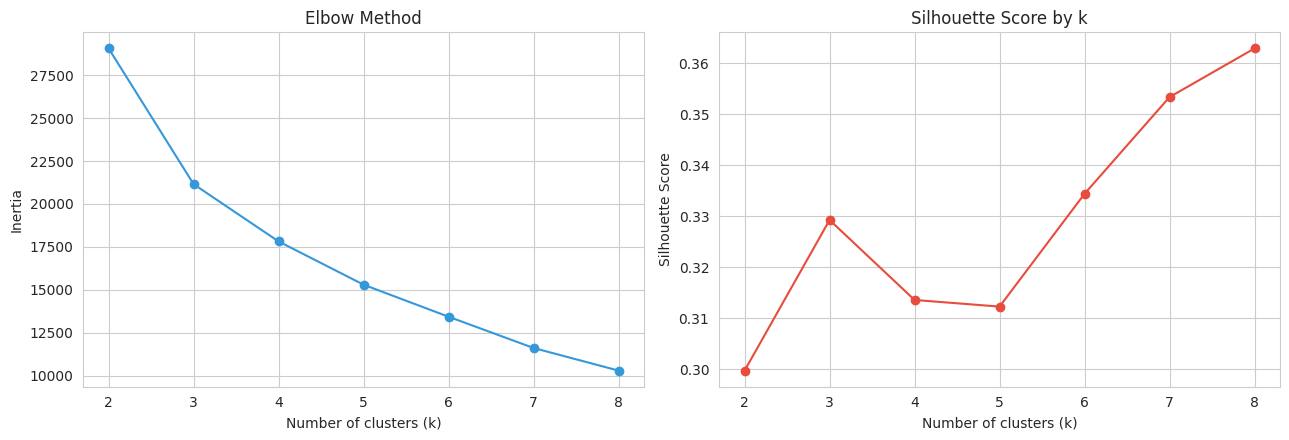

Silhouette score suggests k=8, but we'll use business judgment too --
too few clusters aren't actionable, too many aren't presentable in a pitch.


In [ ]:
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(K_range), inertias, marker='o', color='#3498db')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), silhouettes, marker='o', color='#e74c3c')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f"Silhouette score suggests k={best_k}, but we'll use business judgment too --")
print("too few clusters aren't actionable, too many aren't presentable in a pitch.")

In [ ]:
# k=4 balances statistical support (elbow flattens around here) with something
# a retention team can actually act on -- 4 distinct, nameable customer types.
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df_model['cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(f"Silhouette score at k={K_FINAL}: {silhouette_score(X_cluster_scaled, df_model['cluster']):.3f}")
df_model['cluster'].value_counts().sort_index()

Silhouette score at k=4: 0.314


,count
cluster,
0,1261
1,2034
2,2100
3,1648


### PCA — visualizing clusters in 2D

The clustering happened in 6-dimensional feature space, which we can't plot directly. PCA compresses it down to 2 principal components that capture as much of the original variance as possible, purely so we can *see* the cluster separation.

Variance explained by PC1: 42.1%
Variance explained by PC2: 28.6%
Total variance captured in 2D: 70.7%


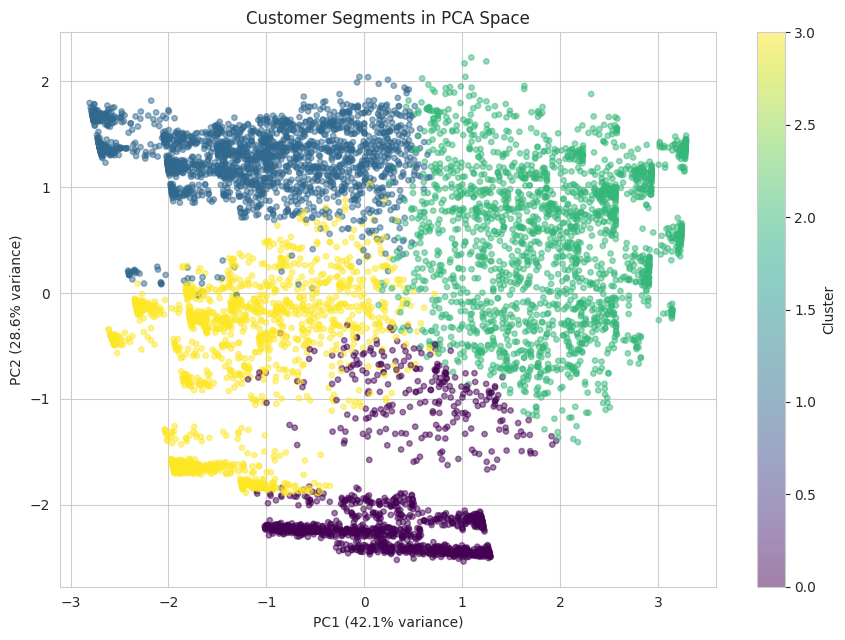

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance captured in 2D: {pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(9, 6.5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_model['cluster'],
                       cmap='viridis', alpha=0.5, s=15)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Customer Segments in PCA Space')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

### Naming the segments

Cluster numbers mean nothing to a business stakeholder. We profile each cluster's average characteristics and its churn rate, then give each one a name a retention team could actually use in a meeting.

In [ ]:
cluster_profile = df_model.groupby('cluster').agg(
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_support_services=('support_services_count', 'mean'),
    pct_month_to_month=('is_month_to_month', 'mean'),
    pct_autopay=('is_autopay', 'mean'),
    churn_rate=('Churn', 'mean'),
    customer_count=('Churn', 'count'),
).round(2)

cluster_profile['pct_month_to_month'] = (cluster_profile['pct_month_to_month'] * 100).round(1)
cluster_profile['pct_autopay'] = (cluster_profile['pct_autopay'] * 100).round(1)
cluster_profile['churn_rate'] = (cluster_profile['churn_rate'] * 100).round(1)

cluster_profile

,avg_tenure,avg_monthly_charges,avg_support_services,pct_month_to_month,pct_autopay,churn_rate,customer_count
cluster,,,,,,,
0,40.26,26.66,0.40,0.0,52.0,2.0,1261
1,18.89,84.81,1.66,98.0,25.0,56.0,2034
2,56.27,87.61,4.17,12.0,69.0,11.0,2100
3,12.52,40.05,1.04,99.0,27.0,29.0,1648


In [ ]:
# Name each segment using a 2x2 quadrant: churn risk (high/low) x customer
# value (high/low avg monthly charges). This guarantees 4 distinct names
# instead of a chained if/elif that can accidentally collapse two clusters
# into the same label.
churn_median = cluster_profile['churn_rate'].median()
value_median = cluster_profile['avg_monthly_charges'].median()

segment_names = {}
for idx, row in cluster_profile.iterrows():
    high_churn = row['churn_rate'] > churn_median
    high_value = row['avg_monthly_charges'] > value_median
    if high_churn and high_value:
        segment_names[idx] = 'High-Value At-Risk'
    elif high_churn and not high_value:
        segment_names[idx] = 'Budget At-Risk'
    elif not high_churn and high_value:
        segment_names[idx] = 'Loyal High-Value'
    else:
        segment_names[idx] = 'Loyal Low-Spend'

df_model['segment_name'] = df_model['cluster'].map(segment_names)
cluster_profile['segment_name'] = cluster_profile.index.map(segment_names)
cluster_profile[['segment_name', 'customer_count', 'churn_rate', 'avg_tenure',
                  'avg_monthly_charges', 'avg_support_services', 'pct_month_to_month']]

,segment_name,customer_count,churn_rate,avg_tenure,avg_monthly_charges,avg_support_services,pct_month_to_month
cluster,,,,,,,
0,Loyal Low-Spend,1261,2.0,40.26,26.66,0.40,0.0
1,High-Value At-Risk,2034,56.0,18.89,84.81,1.66,98.0
2,Loyal High-Value,2100,11.0,56.27,87.61,4.17,12.0
3,Budget At-Risk,1648,29.0,12.52,40.05,1.04,99.0


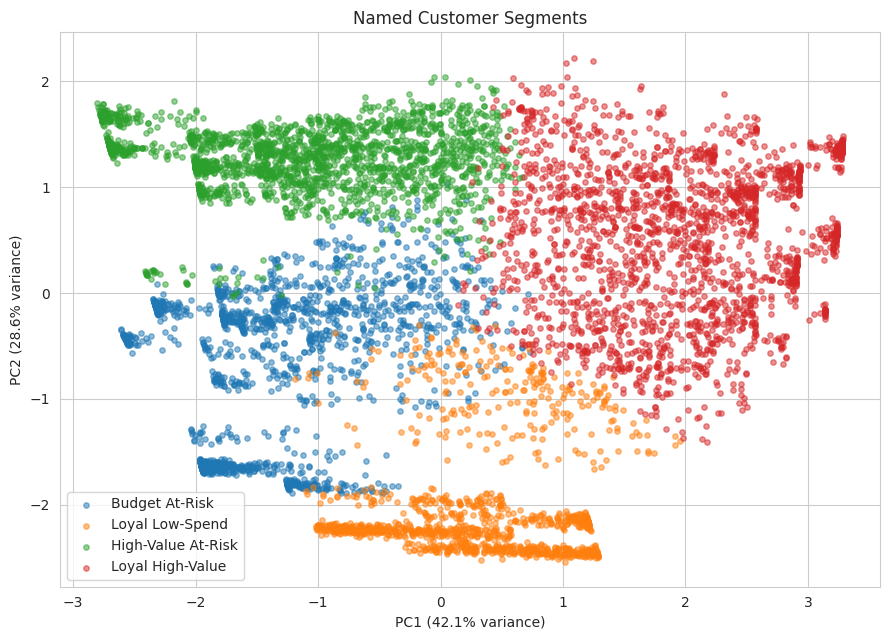

In [ ]:
plt.figure(figsize=(9, 6.5))
for seg in df_model['segment_name'].unique():
    mask = df_model['segment_name'] == seg
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=seg, alpha=0.5, s=15)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Named Customer Segments')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
OFFER_COST = 50          # $ per customer contacted
RETENTION_SUCCESS_RATE = 0.30   # fraction of contacted true-churners who are retained

# Rebuild predictions + actuals + charges aligned on the test set index
test_charges = df.loc[X_test.index, 'MonthlyCharges'].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_pred_lr = log_reg.predict(X_test_scaled)  # best model from Step 5

eval_df = pd.DataFrame({
    'actual_churn': y_test_reset,
    'predicted_churn': y_pred_lr,
    'monthly_charges': test_charges,
})
eval_df['annual_value'] = eval_df['monthly_charges'] * 12

eval_df.head()

,actual_churn,predicted_churn,monthly_charges,annual_value
0,0,0,114.05,1368.6
1,0,1,100.15,1201.8
2,0,0,78.35,940.2
3,0,1,78.20,938.4
4,0,0,82.65,991.8


In [ ]:
def simulate_strategy(df_e, targeted_mask, retention_rate=RETENTION_SUCCESS_RATE, offer_cost=OFFER_COST):
    """
    targeted_mask: boolean mask of which customers get the retention offer.
    Returns campaign cost, revenue saved, revenue lost anyway, and net benefit.
    """
    targeted = df_e[targeted_mask]
    campaign_cost = len(targeted) * offer_cost

    true_churners_targeted = targeted[targeted['actual_churn'] == 1]
    revenue_saved = true_churners_targeted['annual_value'].sum() * retention_rate

    # customers who churn and were NEVER targeted -- pure loss, no chance to intervene
    missed = df_e[(df_e['actual_churn'] == 1) & (~targeted_mask)]
    revenue_lost_untargeted = missed['annual_value'].sum()

    # customers targeted but the offer didn't work (70% of true churners) -- still lost
    revenue_lost_targeted_failed = true_churners_targeted['annual_value'].sum() * (1 - retention_rate)

    net_benefit = revenue_saved - campaign_cost

    return {
        'customers_targeted': len(targeted),
        'campaign_cost': campaign_cost,
        'revenue_saved': revenue_saved,
        'revenue_lost_anyway': revenue_lost_untargeted + revenue_lost_targeted_failed,
        'net_benefit': net_benefit,
    }

# --- Strategy A: Do nothing ---
strategy_none = simulate_strategy(eval_df, pd.Series([False]*len(eval_df)))

# --- Strategy B: Contact EVERY customer (blanket campaign) ---
strategy_all = simulate_strategy(eval_df, pd.Series([True]*len(eval_df)))

# --- Strategy C: Contact only customers the model flags as at-risk ---
strategy_model = simulate_strategy(eval_df, eval_df['predicted_churn'] == 1)

comparison = pd.DataFrame({
    'Do Nothing': strategy_none,
    'Contact Everyone': strategy_all,
    'Model-Targeted': strategy_model,
}).T
comparison[['customers_targeted','campaign_cost','revenue_saved','revenue_lost_anyway','net_benefit']].round(0)

,customers_targeted,campaign_cost,revenue_saved,revenue_lost_anyway,net_benefit
Do Nothing,0.0,0.0,0.0,326579.0,0.0
Contact Everyone,1409.0,70450.0,97974.0,228605.0,27524.0
Model-Targeted,587.0,29350.0,80893.0,245686.0,51543.0


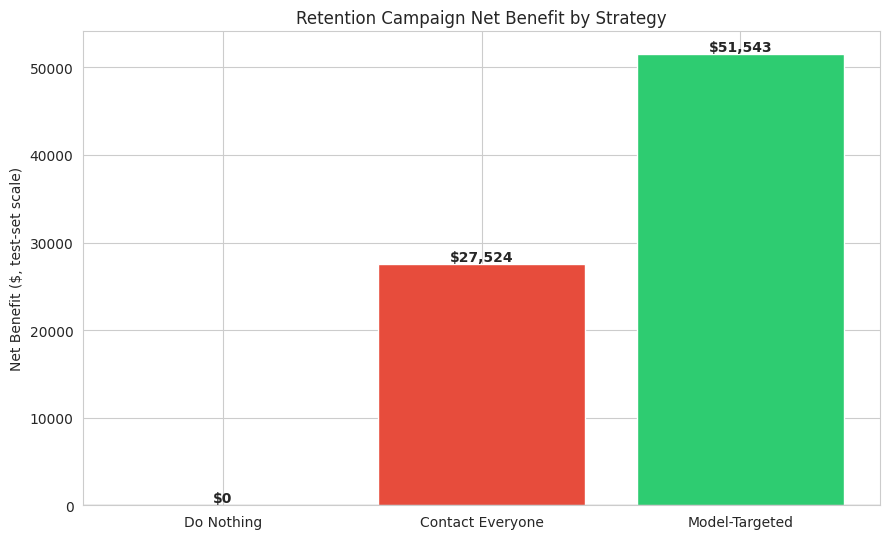

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
strategies = ['Do Nothing', 'Contact Everyone', 'Model-Targeted']
net_benefits = [strategy_none['net_benefit'], strategy_all['net_benefit'], strategy_model['net_benefit']]
colors = ['#95a5a6', '#e74c3c', '#2ecc71']

bars = ax.bar(strategies, net_benefits, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Net Benefit ($, test-set scale)')
ax.set_title('Retention Campaign Net Benefit by Strategy')
for bar, val in zip(bars, net_benefits):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'${val:,.0f}',
             ha='center', va='bottom' if val >= 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

### Sensitivity analysis — does the conclusion hold if our assumptions are wrong?

Real retention success rates vary by company and offer type. Rather than presenting one number as gospel, we check whether the model-targeted strategy stays the best choice across a plausible range.

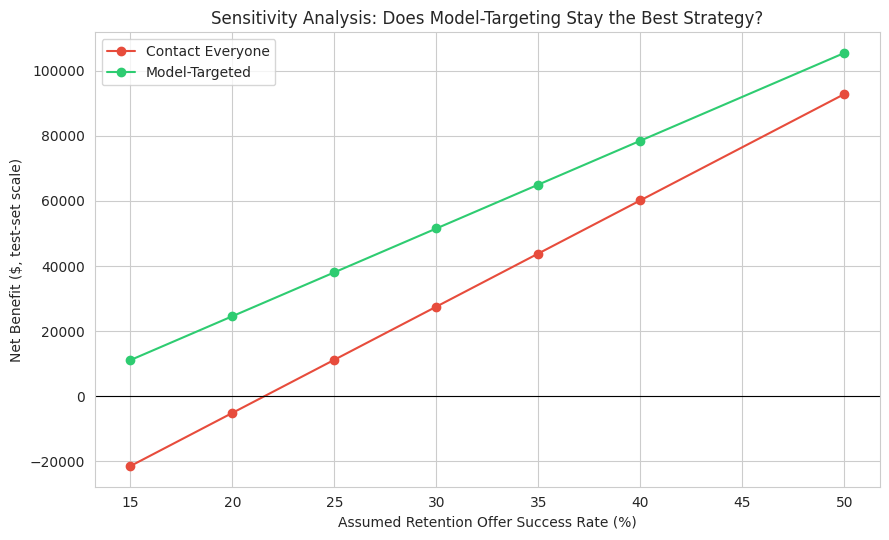

,Contact Everyone,Model-Targeted
retention_rate,,
0.15,-21463.0,11097.0
0.20,-5134.0,24579.0
0.25,11195.0,38061.0
0.30,27524.0,51543.0
0.35,43853.0,65025.0
0.40,60182.0,78507.0
0.50,92839.0,105472.0


In [ ]:
rates_to_test = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
sensitivity_rows = []
for r in rates_to_test:
    s_all = simulate_strategy(eval_df, pd.Series([True]*len(eval_df)), retention_rate=r)
    s_model = simulate_strategy(eval_df, eval_df['predicted_churn'] == 1, retention_rate=r)
    sensitivity_rows.append({
        'retention_rate': r,
        'Contact Everyone': s_all['net_benefit'],
        'Model-Targeted': s_model['net_benefit'],
    })

sensitivity_df = pd.DataFrame(sensitivity_rows).set_index('retention_rate')

plt.figure(figsize=(9, 5.5))
plt.plot(sensitivity_df.index * 100, sensitivity_df['Contact Everyone'], marker='o', label='Contact Everyone', color='#e74c3c')
plt.plot(sensitivity_df.index * 100, sensitivity_df['Model-Targeted'], marker='o', label='Model-Targeted', color='#2ecc71')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Assumed Retention Offer Success Rate (%)')
plt.ylabel('Net Benefit ($, test-set scale)')
plt.title('Sensitivity Analysis: Does Model-Targeting Stay the Best Strategy?')
plt.legend()
plt.tight_layout()
plt.show()

sensitivity_df.round(0)

In [ ]:
# revenue at risk specifically in the High-Value At-Risk segment
hv_segment = df_model[df_model['segment_name'] == 'High-Value At-Risk']
expected_annual_loss_hv = (hv_segment['Churn'] * hv_segment['MonthlyCharges'] * 12).sum()

print(f"High-Value At-Risk segment: {len(hv_segment):,} customers")
print(f"Actual churners within this segment: {hv_segment['Churn'].sum():,} ({hv_segment['Churn'].mean():.1%})")
print(f"Annual revenue already lost to churn within this single segment: ${expected_annual_loss_hv:,.0f}")
print()
print("This is the single highest-leverage group for a retention campaign --")
print("high value AND high risk, simultaneously. Prioritize here first.")

High-Value At-Risk segment: 2,034 customers
Actual churners within this segment: 1,132 (55.7%)
Annual revenue already lost to churn within this single segment: $1,156,813

This is the single highest-leverage group for a retention campaign --
high value AND high risk, simultaneously. Prioritize here first.


In [ ]:
import joblib

# Save the deployed model (Logistic Regression -- our Step 5 pick) + its scaler
joblib.dump(log_reg, 'churn_model.pkl')
joblib.dump(scaler, 'churn_scaler.pkl')

# Save the exact feature column order the model expects -- critical, since a
# single mismatched column order silently produces wrong predictions
feature_columns = list(X.columns)
joblib.dump(feature_columns, 'feature_columns.pkl')

# Small background sample for SHAP's LinearExplainer (doesn't need the full training set)
background_sample = pd.DataFrame(X_train_scaled, columns=feature_columns).sample(
    n=200, random_state=RANDOM_STATE
)
joblib.dump(background_sample, 'shap_background.pkl')

print("Saved: churn_model.pkl, churn_scaler.pkl, feature_columns.pkl, shap_background.pkl")
print(f"Model expects {len(feature_columns)} features in this exact order.")

Saved: churn_model.pkl, churn_scaler.pkl, feature_columns.pkl, shap_background.pkl
Model expects 36 features in this exact order.
